In [1]:
import json
import pandas as pd
import numpy as np

# data_path = '/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/student_directories/zeidler/too_big_for_git/preprocess/ALC_features_Functional.json'

data_path = '/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/student_directories/zeidler/too_big_for_git/features/all_feature_files/'


In [2]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

In [3]:
import os
train_df = pd.read_json(os.path.join(data_path, 'ALC_features_Functional_train.json'), orient='index')
valid_df = pd.read_json(os.path.join(data_path, 'ALC_features_Functional_valid.json'), orient='index')
test_df = pd.read_json(os.path.join(data_path, 'ALC_features_Functional_test.json'), orient='index')

In [4]:
# from sklearn.model_selection import train_test_split

# train, test = train_test_split(df, test_size=0.2)

In [5]:
print (f'''Train contains {len(train_df)} examples.
Test contains {len(test_df)} examples. 
Valid contains {len(valid_df)} examples.''')

Train contains 12144 examples.
Test contains 1518 examples. 
Valid contains 1518 examples.


In [6]:
train = train_df
valid = valid_df
test = test_df

In [7]:
train['features'][0]

{'F0semitoneFrom27.5Hz_sma3nz_amean': [32.492733001708984],
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm': [0.21872797608375502],
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0': [31.683582305908203],
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0': [33.76922607421875],
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0': [35.998409271240234],
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2': [4.314826965332031],
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope': [881.3382568359375],
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope': [924.7183837890625],
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope': [453.4888610839844],
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope': [648.1083984375],
 'loudness_sma3_amean': [0.540248751640319],
 'loudness_sma3_stddevNorm': [0.93066269159317],
 'loudness_sma3_percentile20.0': [0.070065610110759],
 'loudness_sma3_percentile50.0': [0.396757453680038],
 'loudness_sma3_percentile80.0': [1.034151554107666],
 'loudness_sma3_pctlrange0-2': [0.9640859365463251],
 'loudness_sma

# Majority Baseline 
(Just one dummy feature)

In [8]:
# this keeps one first feature -- should not be informative enough for the model to work
def features_to_vec(feature_dict):
#     out_vector = []
#     for feature in feature_dict.values():
#         out_vector.append(feature)
    return [0]

In [9]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[5])} dimensions.")

The dataset has 12144 data samples.
Each data sample is a vector of 1 dimensions.


In [10]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = valid['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in valid['intoxicated']]

In [11]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [12]:
X_train[2:4]
#look at this; maybe we could collapse redundant features? like do PCA or any other dimensionality reduction

[[0], [0]]

In [13]:
y_train[:2]

[0, 1]

In [14]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [15]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)
accuracy = nb_classifier.score(X_test, y_test)
accuracy

0.689064558629776

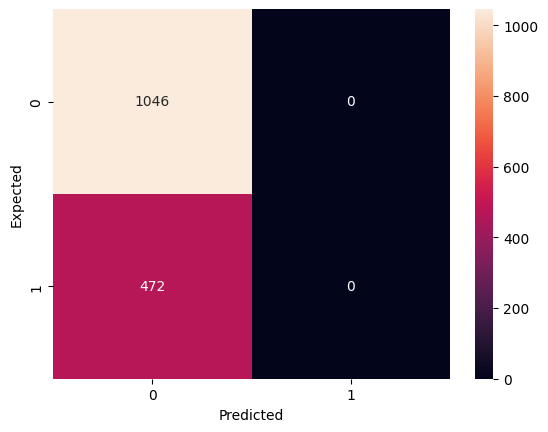

In [16]:
evaluate_classifier(nb_classifier, X_test, y_test)

# Actual Baseline

In [17]:
# this simply flattens all the features into one long concatenated vector
def features_to_vec(feature_dict):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

features_to_vec(train['features'][0])

[32.492733001708984,
 0.21872797608375502,
 31.683582305908203,
 33.76922607421875,
 35.998409271240234,
 4.314826965332031,
 881.3382568359375,
 924.7183837890625,
 453.4888610839844,
 648.1083984375,
 0.540248751640319,
 0.93066269159317,
 0.070065610110759,
 0.396757453680038,
 1.034151554107666,
 0.9640859365463251,
 11.132161140441895,
 6.461780071258545,
 14.554564476013184,
 9.387868881225586,
 0.36572742462158203,
 1.0607548952102661,
 27.66328239440918,
 0.488133907318115,
 4.589967250823975,
 3.030091285705566,
 11.025267601013184,
 1.165165185928344,
 0.34839758276939303,
 40.699249267578125,
 0.041384119540452007,
 1.9354156255722041,
 1.4423853158950801,
 0.8959958553314201,
 5.469961643218994,
 1.220382094383239,
 3.6638307571411133,
 7.927948474884033,
 17.69322395324707,
 1.342873096466064,
 647.472412109375,
 0.255685746669769,
 1333.5526123046875,
 0.15527164936065602,
 -99.15857696533203,
 -0.9113807678222651,
 1670.0865478515625,
 0.141956761479377,
 1033.3723144531

In [18]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[7])} dimensions.")

The dataset has 12144 data samples.
Each data sample is a vector of 88 dimensions.


In [19]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = valid['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in valid['intoxicated']]

In [20]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [21]:
#([set([type(x) for x in y]) for y in X_train])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [22]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)
accuracy = nb_classifier.score(X_test, y_test)
accuracy

0.6587615283267457

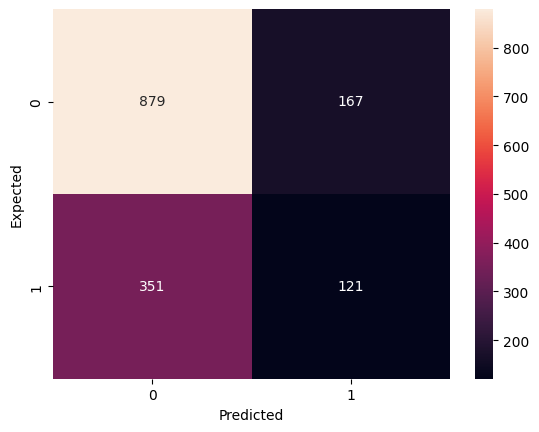

In [23]:
evaluate_classifier(nb_classifier, X_test, y_test)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [25]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
accuracy = knn_classifier.score(X_test, y_test)
accuracy

0.6383399209486166

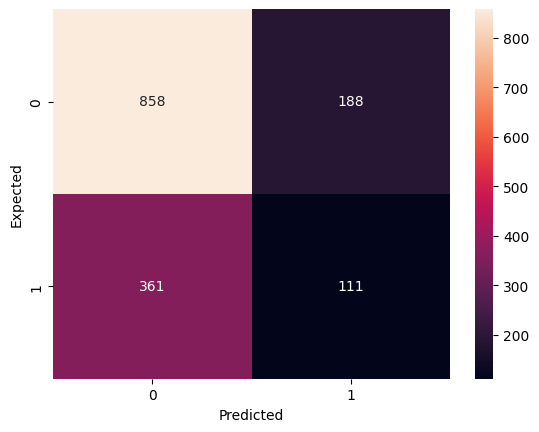

In [26]:
evaluate_classifier(knn_classifier, X_test, y_test)

In [27]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)
accuracy = rf_classifier.score(X_test, y_test)
accuracy 

0.7496706192358367

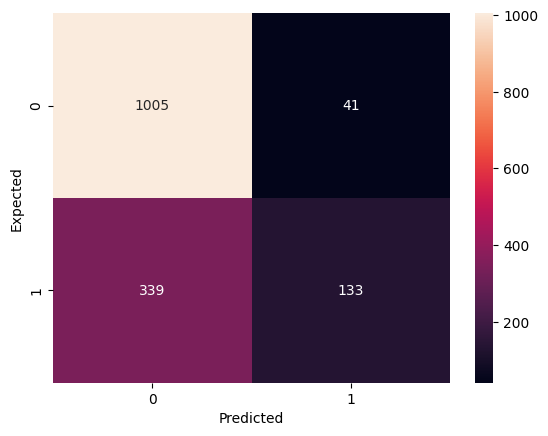

In [28]:
evaluate_classifier(rf_classifier, X_test, y_test)

In [29]:
svm_classifier = svm.LinearSVC()
svm_classifier.fit(X_train, y_train)
accuracy = svm_classifier.score(X_test, y_test)
accuracy

/mount/arbeitsdaten31/studenten1/team-lab-phonetics/2023/student_directories/kolos/NLP4/lib64/python3.10/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.6923583662714098

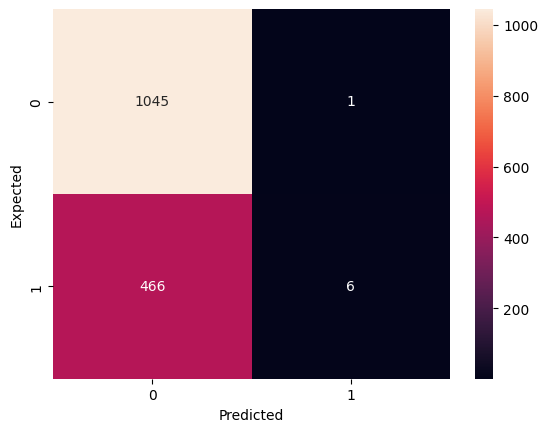

In [30]:
evaluate_classifier(svm_classifier, X_test, y_test)

In [31]:
svm_classifier = svm.NuSVC(kernel='poly')
svm_classifier.fit(X_train, y_train)
accuracy = svm_classifier.score(X_test, y_test)
accuracy

0.689064558629776

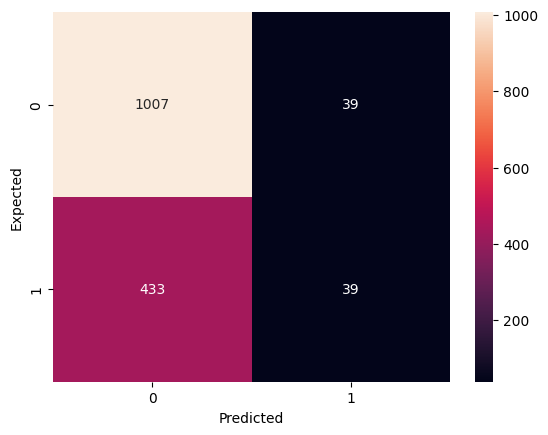

In [32]:
evaluate_classifier(svm_classifier, X_test, y_test)

In [33]:
logreg_classifier = LogisticRegression()
logreg_classifier.fit(X_train, y_train)
accuracy = logreg_classifier.score(X_test, y_test)
accuracy

/mount/arbeitsdaten31/studenten1/team-lab-phonetics/2023/student_directories/kolos/NLP4/lib64/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7002635046113307

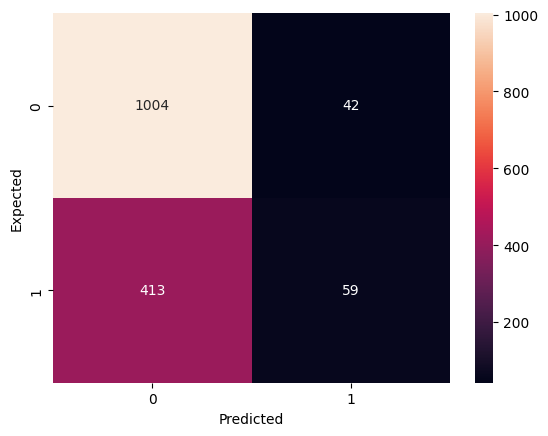

In [34]:
evaluate_classifier(logreg_classifier, X_test, y_test)

# Majority Baseline for the Levels (Regression Task)

In [35]:
from sklearn import linear_model

In [36]:
linmodel = linear_model.LinearRegression(fit_intercept=True)

In [37]:
def features_to_vec(feature_dict, i=0):
    out_vector = [list(feature_dict.values())[i][0]] #first of i-th feature only
    return out_vector

X_train = train['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
y_train = train['breath alcohol concentration']
y_test = valid['breath alcohol concentration']
linmodel.fit(X_train, y_train)

LinearRegression()

In [38]:
(slope, intercept) = (linmodel.coef_[0], linmodel.intercept_)
print(slope, intercept)

-0.0001818902759777836 0.0003182650542259565


In [39]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 0.00
Coefficient of determination: -0.00


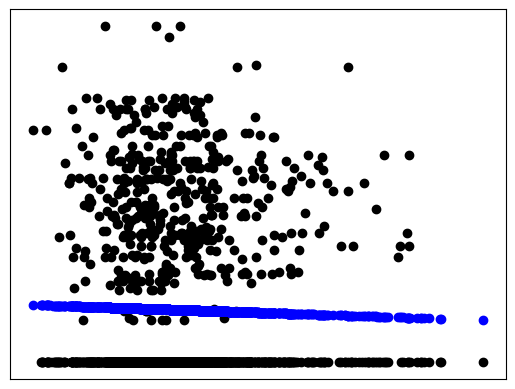

In [40]:
import matplotlib.pyplot as plt
# Plot outputs
#based on the one dimension of features
x_test_0 = [x[0] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [41]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = valid['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur

24 0.021979120179781653
Mean squared error: 0.00
Coefficient of determination: 0.02


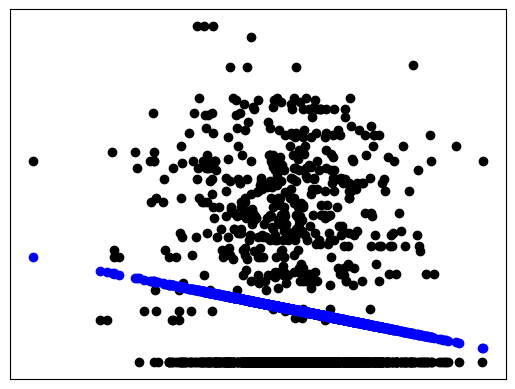

In [42]:
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = valid['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

## On only those who have non-0 alc level
### In the breath
Feature 38 seems to be correlated with the alcohol level in blood

In [43]:
df = df[df['breath alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)

NameError: name 'df' is not defined

In [ ]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = valid['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = valid['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### In the blood
Also feature 38, but less correlated

In [ ]:
df = pd.read_json(data_path, orient='index')
df = df[df['blood alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)

#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['blood alcohol concentration']
    y_test = valid['blood alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['blood alcohol concentration']
y_test = valid['blood alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

In [ ]:
#What is this feature 38?
list(df['features'][0].keys())[38]

## Multiple Linear Regression

### On all features and all data

In [ ]:
X_train = train['features'].apply(features_to_vec).tolist() 
X_test = valid['features'].apply(features_to_vec).tolist() 
y_train = train['breath alcohol concentration']
y_test = valid['breath alcohol concentration']
linmodel.fit(X_train, y_train)

In [ ]:
(slope, intercept) = (linmodel.coef_[0], linmodel.intercept_)
print(slope, intercept)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
y_pred = linmodel.predict(X_test)

In [ ]:
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

In [ ]:
import matplotlib.pyplot as plt

Note: Visualization problematic. Only one feature (dimension) can be selected for 0x while we have many (88)

In [ ]:
# Plot outputs
#based on the one dimension of features
x_test_0 = [x[0] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative blood alcohol level on all features

In [ ]:
#NB: there's randomness here
df = pd.read_json(data_path, orient='index')
df = df[df['blood alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict, i=0):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

#Find the feature that produces the best results (the best r2_score)
r2_score_max = -100
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['blood alcohol concentration']
    y_test = valid['blood alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['blood alcohol concentration']
y_test = valid['blood alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative breath alcohol level on all features

In [ ]:
df = pd.read_json(data_path, orient='index')
df = df[df['breath alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict, i=0):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

#Find the feature that produces the best results (the best r2_score)
r2_score_max = -100
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = valid['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = valid['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative blood alcohol level on values of feature 38

In [ ]:
df = pd.read_json(data_path, orient='index')
df = df[df['blood alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict):
    out_vector = []
    feature = list(feature_dict.values())[38]
    for subfeature in feature:
        out_vector.append(subfeature)
    return out_vector


linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x)).tolist() 
y_train = train['blood alcohol concentration']
y_test = valid['blood alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative breath alcohol level on values of feature 38

In [ ]:
df = pd.read_json(data_path, orient='index')
df = df[df['breath alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict):
    out_vector = []
    feature = list(feature_dict.values())[38]
    for subfeature in feature:
        out_vector.append(subfeature)
    return out_vector


linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x)).tolist() 
X_test = valid['features'].apply(lambda x: features_to_vec(x)).tolist() 
y_train = train['breath alcohol concentration']
y_test = valid['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()